In [41]:

import torch
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd   # We import Pandas!
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import linear_model
import itertools
from pyro.infer.autoguide import AutoNormal
import pyro
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO, Predictive
from pyro.optim import Adam, ClippedAdam
data=pd.read_csv("../data/movies_with_genres_and_cast.csv")

In [42]:
train_data=pd.read_csv("../data/movies_with_genres_and_cast_train.csv")
val_data=pd.read_csv("../data/movies_with_genres_and_cast_val.csv")
test_data=pd.read_csv("../data/movies_with_genres_and_cast_test.csv")

In [ ]:
data = data[(data['revenue'] != 0) & (data['revenue'].notna())]
len(data)
K=10

In [44]:
def filter_actors(data, threshold):
    # Combine all actor columns into a single series
    all_actors = pd.concat([data[f'Actor_{i}'] for i in range(1, 6)])
    
    # Count occurrences of each actor
    actor_counts = all_actors.value_counts()
    
    # Filter actors based on the threshold
    valid_actors = actor_counts[actor_counts >= threshold].index
    
    # Replace invalid actors with NaN
    for i in range(1, 6):
        data[f'Actor_{i}'] = data[f'Actor_{i}'].where(data[f'Actor_{i}'].isin(valid_actors), other=pd.NA)
    
    return data


# Example usage
threshold =  11 # Replace with your desired threshold
data = filter_actors(data, threshold)
train_data = filter_actors(train_data, threshold)
test_data = filter_actors(test_data, threshold)
val_data = filter_actors(val_data, threshold)

In [45]:
actor_cols = ["Actor_1", "Actor_2", "Actor_3", "Actor_4", "Actor_5"]

# Get all unique actor IDs except 0
unique_actors = pd.unique(data[actor_cols].values.ravel())
unique_actors = [a for a in unique_actors if a != 0]


def expand_actor_rows(actors, genres, revenue, impact):
    N, As = actors.shape

    actor_flat = actors.reshape(-1)
    genre_flat = genres.unsqueeze(1).expand(-1, K, -1).reshape(-1, genres.shape[1])
    revenue_flat = revenue.unsqueeze(1).expand(-1, K).reshape(-1)
    impact_flat = impact.unsqueeze(1).expand(-1, K).reshape(-1)

    mask = actor_flat != 0
    return actor_flat[mask], genre_flat[mask], revenue_flat[mask], impact_flat[mask]


def preprocess_data(data, unique_actors, K=10, mean_revenue=None ):
    actor_cols = ["Actor_1", "Actor_2", "Actor_3", "Actor_4", "Actor_5"]
    genre_cols=data.columns[12:12+K+1]

    # 0 is reserved for missing/unknown actor
    actor_map = {old_id: new_id for new_id, old_id in enumerate(unique_actors, start=1)}
    actor_map[0] = 0
    # Number of actors including missing actor 0
    n_actors = len(actor_map)

    data[actor_cols] = data[actor_cols].fillna(0)
    data[actor_cols] = data[actor_cols].replace(actor_map)

    actor_ids = torch.tensor(data[actor_cols].values, dtype=torch.long)
    genre_matrix = torch.tensor(data[genre_cols].values, dtype=torch.float32)
    log_revenue = torch.tensor(np.log1p(data["revenue"].values), dtype=torch.float32)
    log_impact = log_revenue - mean_revenue
    return actor_ids, genre_matrix, log_revenue, log_impact

train_log_revenue = torch.tensor(np.log1p(train_data["revenue"].values), dtype=torch.float32)
train_actors, train_genres, train_revenue, train_impact = preprocess_data(train_data, unique_actors, K, train_log_revenue.mean())
val_actors, val_genres, val_revenue, val_impact = preprocess_data(val_data, unique_actors, K, train_log_revenue.mean())
test_actors, test_genres, test_revenue, test_impact = preprocess_data(test_data, unique_actors, K, train_log_revenue.mean())

In [46]:
def expand_actor_rows(actors, genres, revenue, impact):
    for actors, genres, revenue, impact in zip(actors, genres, revenue, impact):
        for actor in actors:
            if actor != 0:
                yield actor, genres, revenue, impact


In [47]:
def expand_actor_rows(actors_batch, genres_batch, revenue_batch, impact_batch):
    actor_rows = []
    genre_rows = []
    revenue_rows = []
    impact_rows = []

    for actors, genres, revenue, impact in zip(
        actors_batch, genres_batch, revenue_batch, impact_batch
    ):
        for actor in actors:
            if actor != 0:
                actor_rows.append(actor)
                genre_rows.append(genres)
                revenue_rows.append(revenue)
                impact_rows.append(impact)

    return (
        torch.stack(actor_rows),
        torch.stack(genre_rows),
        torch.stack(revenue_rows),
        torch.stack(impact_rows),
    )

In [49]:
import torch
import pyro
import pyro.distributions as dist

def actor_genre_model(genre_matrix, actor_id, num_actors, obs=None):
    actor_id = actor_id.long()

    N, num_genres = genre_matrix.shape

    alpha = pyro.sample("alpha", dist.Normal(0.0, 10.0))

    beta_genre = pyro.sample(
        "beta_genre",
        dist.Normal(
            torch.zeros(num_genres, device=genre_matrix.device),
            torch.ones(num_genres, device=genre_matrix.device)
        ).to_event(1)
    )

    actor_scale = pyro.sample("actor_scale", dist.HalfCauchy(5.0))

    actor_effect = pyro.sample(
        "actor_effect",
        dist.Normal(
            torch.zeros(num_actors, device=genre_matrix.device),
            actor_scale * torch.ones(num_actors, device=genre_matrix.device)
        ).to_event(1)
    )

    actor_genre_scale = pyro.sample("actor_genre_scale", dist.HalfCauchy(5.0))

    actor_genre_effect = pyro.sample(
        "actor_genre_effect",
        dist.Normal(
            torch.zeros(num_actors, num_genres, device=genre_matrix.device),
            actor_genre_scale * torch.ones(num_actors, num_genres, device=genre_matrix.device)
        ).to_event(2)
    )

    sigma = pyro.sample("sigma", dist.HalfCauchy(5.0))

    genre_part = genre_matrix.matmul(beta_genre)

    # Handle unseen actors safely
    known_actor_mask = actor_id < num_actors
    safe_actor_id = actor_id.clone()
    safe_actor_id[~known_actor_mask] = 0

    actor_part = actor_effect[safe_actor_id]
    actor_part = torch.where(
        known_actor_mask,
        actor_part,
        torch.zeros_like(actor_part)
    )

    interaction_part = (
        genre_matrix * actor_genre_effect[safe_actor_id]
    ).sum(dim=1)

    # interaction_part = torch.where(
    #     known_actor_mask,
    #     interaction_part,
    #     torch.zeros_like(interaction_part)
    # )

    mu = alpha + genre_part + actor_part #+ interaction_part

    with pyro.plate("data", N):
        y = pyro.sample("y", dist.Normal(mu, sigma), obs=obs)

    return y

In [50]:
train_actor, train_genrev2, train_revenuev2, train_impactv2 = expand_actor_rows(train_actors, train_genres, train_revenue, train_impact)
test_actor, test_genrev2, test_revenuev2, test_impactv2 = expand_actor_rows(test_actors, test_genres, test_revenue, test_impact)
val_actor, val_genrev2, val_revenuev2, val_impactv2 = expand_actor_rows(val_actors, val_genres, val_revenue, val_impact)

In [51]:
num_train_actors = int(train_actor.max().item()) + 1

In [ ]:

train_actor = train_actor.long()
train_genrev2 = train_genrev2.float()
train_impactv2 = train_impactv2.float()

num_train_actors = int(train_actor.max().item()) + 1

pyro.clear_param_store()

guide = AutoNormal(actor_genre_model)

optimizer = Adam({"lr": 0.01})

svi = SVI(
    actor_genre_model,
    guide,
    optimizer,
    loss=Trace_ELBO()
)

num_steps = 1000

for step in range(num_steps):
    loss = svi.step(
        train_genrev2,
        train_actor,
        num_train_actors,
        train_impactv2
    )

    if step % 250 == 0:
        print(f"step {step} loss = {loss:.2f}")

step 0 loss = 44623.89
step 250 loss = 13155.87
step 500 loss = 13143.79
step 750 loss = 13014.92
step 1000 loss = 12986.65
step 1250 loss = 12959.51
step 1500 loss = 12992.12
step 1750 loss = 12935.03
step 2000 loss = 12938.65
step 2250 loss = 12921.53
step 2500 loss = 12933.09
step 2750 loss = 12914.25


Model MAE: 2.292274236679077
Baseline MAE: 2.949566602706909
MAE improvement: 0.657292366027832
MAE improvement %: 22.28437042236328

Model RMSE: 3.7912378311157227
Baseline RMSE: 3.9899590015411377
RMSE improvement: 0.19872117042541504
RMSE improvement %: 4.980531215667725


In [72]:
test_actor = test_actor.long()
test_genrev2 = test_genrev2.float()
test_impactv2 = test_impactv2.float()

predictive = Predictive(
    actor_genre_model,
    guide=guide,
    num_samples=500,
    return_sites=("y", "alpha", "beta_genre", "actor_effect",  "sigma")
)

posterior_samples = predictive(
    test_genrev2,
    test_actor,
    num_train_actors,
    obs=None
)

y_samples = posterior_samples["y"]
y_mean = y_samples.mean(dim=0)
y_std = y_samples.std(dim=0)

In [73]:
# Predictions from Bayesian model
y_samples = posterior_samples["y"]
y_mean = y_samples.mean(dim=0)
y_std = y_samples.std(dim=0)

# True values
y_true = test_impactv2

# Model metrics
model_mae = torch.mean(torch.abs(y_mean - y_true))
model_rmse = torch.sqrt(torch.mean((y_mean - y_true) ** 2))

# Baseline: predict 0 for every occurrence
baseline_pred = torch.zeros_like(y_true)

baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))

# Improvement
mae_improvement = baseline_mae - model_mae
rmse_improvement = baseline_rmse - model_rmse

mae_improvement_pct = 100 * mae_improvement / baseline_mae
rmse_improvement_pct = 100 * rmse_improvement / baseline_rmse

print("Model MAE:", model_mae.item())
print("Baseline MAE:", baseline_mae.item())
print("MAE improvement:", mae_improvement.item())
print("MAE improvement %:", mae_improvement_pct.item())

print()

print("Model RMSE:", model_rmse.item())
print("Baseline RMSE:", baseline_rmse.item())
print("RMSE improvement:", rmse_improvement.item())
print("RMSE improvement %:", rmse_improvement_pct.item())

Model MAE: 2.299950361251831
Baseline MAE: 2.949566602706909
MAE improvement: 0.6496162414550781
MAE improvement %: 22.024126052856445

Model RMSE: 3.8022499084472656
Baseline RMSE: 3.9899590015411377
RMSE improvement: 0.18770909309387207
RMSE improvement %: 4.704536437988281


In [74]:
def predict_first_valid_actor(predictive, genre_matrix, actor_ids, num_actors, num_samples=500, default_actor=0):
    """Predict using the first nonzero actor for each movie.

    If a movie has no valid actor, use `default_actor` instead.
    """
    if actor_ids.dim() != 2:
        raise ValueError("actor_ids must be a 2D tensor [N, K]")

    N, K = actor_ids.shape
    valid_mask = actor_ids != 0

    # Find the first nonzero actor index per movie.
    first_nonzero_idx = valid_mask.int().argmax(dim=1)
    has_valid_actor = valid_mask.any(dim=1)

    first_actor = torch.zeros(N, dtype=actor_ids.dtype, device=actor_ids.device)
    first_actor[has_valid_actor] = actor_ids[has_valid_actor, first_nonzero_idx[has_valid_actor]]

    # If no valid actor in a movie, use default_actor.
    first_actor[~has_valid_actor] = default_actor

    # Model expects actor_ids shape [N, K]; use one actor per movie.
    first_actor_ids = first_actor.unsqueeze(1)

    samples = predictive(
        genre_matrix,
        first_actor_ids,
        num_actors,
        obs=None
    )

    y = samples["y"]
    return {
        "first_actor_ids": first_actor_ids,
        "y_samples": y,
        "y_mean": y.mean(dim=0),
        "y_std": y.std(dim=0),
    }

# Example usage for the test split:
first_actor_prediction = predict_first_valid_actor(
    predictive,
    test_genrev2,
    test_actors,
    num_train_actors,
    num_samples=500,
    default_actor=0,
)

In [ ]:
y_true = test_impactv2

y_mean = first_actor_prediction['y_mean']
model_mae = torch.mean(torch.abs(y_mean - y_true))
model_rmse = torch.sqrt(torch.mean((y_mean - y_true) ** 2))

# Baseline: predict 0 for every occurrence
baseline_pred = torch.zeros_like(y_true)

baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))

# Improvement
mae_improvement = baseline_mae - model_mae
rmse_improvement = baseline_rmse - model_rmse

mae_improvement_pct = 100 * mae_improvement / baseline_mae
rmse_improvement_pct = 100 * rmse_improvement / baseline_rmse

print("Model MAE:", model_mae.item())
print("Baseline MAE:", baseline_mae.item())
print("MAE improvement:", mae_improvement.item())
print("MAE improvement %:", mae_improvement_pct.item())


print("Model RMSE:", model_rmse.item())
print("Baseline RMSE:", baseline_rmse.item())
print("RMSE improvement:", rmse_improvement.item())
print("RMSE improvement %:", rmse_improvement_pct.item())

Model MAE: 2.3205478191375732
Baseline MAE: 2.949566602706909
MAE improvement: 0.6290187835693359
MAE improvement %: 21.325803756713867

Model RMSE: 3.778480291366577
Baseline RMSE: 3.9899590015411377
RMSE improvement: 0.21147871017456055
RMSE improvement %: 5.3002729415893555


In [20]:
posterior_train = Predictive(
    actor_genre_model,
    guide=guide,
    num_samples=1000,
    return_sites=("alpha", "beta_genre", "actor_effect", "actor_genre_effect", "sigma")
)(
    train_genrev2,
    train_actor,
    num_train_actors,
    obs=None
)

actor_effect_mean = posterior_train["actor_effect"].mean(dim=0)
actor_effect_std = posterior_train["actor_effect"].std(dim=0)

beta_genre_mean = posterior_train["beta_genre"].mean(dim=0)
beta_genre_std = posterior_train["beta_genre"].std(dim=0)

actor_genre_effect_mean = posterior_train["actor_genre_effect"].mean(dim=0)
actor_genre_effect_std = posterior_train["actor_genre_effect"].std(dim=0)

In [ ]:
train_actor_ids = train_actors.long()       # shape [N, K]
train_genrev2 = train_genres.float()        # shape [N, G]
train_impactv2 = train_impact.float()       # shape [N]


In [ ]:
def create_movie_distributions(actor_genre_effect_mean, actor_genre_effect_std, actor_effect_mean, actor_effect_std, beta_genre_mean, beta_genre_std, num_train_actors, actor_ids,genres_matrix, impact_list):
    actor_movie_distribution = [[] for _ in range(len(impact_list))]
    actor_genre_movie_distribution = [[] for _ in range(len(impact_list))]
    genre_movie_distribution = [[] for _ in range(len(genres_matrix))]
    for movie_i, (actors, genres, impact) in enumerate(zip(actor_ids, genres_matrix, impact_list)):
        for actor in actors:
            actor = int(actor.item()) if torch.is_tensor(actor) else int(actor)

            if actor != 0 and actor < num_train_actors:
                actor_movie_distribution[movie_i].append(
                    dist.Normal(
                        actor_effect_mean[0][actor],
                        actor_effect_std[0][actor]
                    )
                )
                for genre_i in range(genres.shape[0]):
                    actor_genre_movie_distribution[movie_i].append(
                        dist.Normal(
                            actor_genre_effect_mean[0][actor][genre_i],
                            actor_genre_effect_std[0][actor][genre_i]
                        )
                    )
        for genre_i, genre in enumerate(genres):
            if genre != 0:
                genre_movie_distribution[movie_i].append(
                    dist.Normal(
                        beta_genre_mean[0][genre_i]*genre,
                        beta_genre_std[0][genre_i]*genre
                    )
                )
    return actor_movie_distribution, actor_genre_movie_distribution, genre_movie_distribution   



In [ ]:

def sum_normal_components(distributions):
    """Combine a list of independent Normal distributions into one Normal.

    Each distribution must be a pyro.distributions.Normal instance.
    The resulting distribution has mean = sum(loc_i) and variance = sum(scale_i^2).
    """
    if len(distributions) == 0:
        raise ValueError("No distributions to combine")

    means = []
    variances = []

    for d in distributions:
        if not isinstance(d, dist.Normal):
            raise TypeError("All inputs must be pyro.distributions.Normal instances")
        means.append(d.loc)
        variances.append(d.scale.pow(2))

    total_mean = torch.stack(means).sum(dim=0)
    total_variance = torch.stack(variances).sum(dim=0)
    total_scale = torch.sqrt(total_variance)

    return dist.Normal(total_mean, total_scale)


def combine_movie_distributions(actor_dists, actor_genre_dists, genre_dists):
    """Combine distribution lists for each movie into one Normal per movie."""
    combined = []
    for movie_idx, (a_list, ag_list, g_list) in enumerate(zip(actor_dists, actor_genre_dists, genre_dists)):
        combined_list = []
        combined_list.extend(a_list)
        combined_list.extend(ag_list)
        combined_list.extend(g_list)
        combined.append(sum_normal_components(combined_list))
    return combined


def sample_and_sum_movie_distributions(actor_dists, actor_genre_dists, genre_dists, num_samples=100):
    """Sample each movie's distributions and return the summed samples.

    actor_dists, actor_genre_dists, genre_dists should be lists of lists where
    each inner list contains Normal distributions for one movie.

    Returns a tensor of shape [num_movies, num_samples].
    """
    movie_samples = []
    for movie_idx, (a_list, ag_list, g_list) in enumerate(zip(actor_dists, actor_genre_dists, genre_dists)):
        all_dists = list(a_list) + list(ag_list) + list(g_list)
        if len(all_dists) == 0:
            movie_samples.append(torch.zeros(num_samples))
            continue

        samples = [d.sample(sample_shape=(num_samples,)) for d in all_dists]
        summed = torch.stack(samples, dim=0).sum(dim=0)
        movie_samples.append(summed)

    return torch.stack(movie_samples, dim=0)


In [ ]:
actor_movie_distribution, actor_genre_movie_distribution, genre_movie_distribution = create_movie_distributions(
    actor_genre_effect_mean, actor_genre_effect_std, actor_effect_mean, actor_effect_std, beta_genre_mean, beta_genre_std, num_train_actors, test_actors, test_genrev2, test_impactv2
)

In [ ]:
movie_samples = sample_and_sum_movie_distributions(
    actor_movie_distribution,
    actor_genre_movie_distribution,
    genre_movie_distribution,
    num_samples=2000
)

In [ ]:
movie_samples.shape

torch.Size([13, 2000])

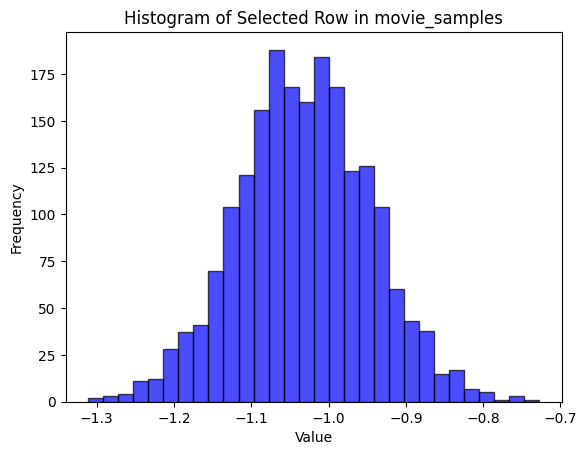

In [ ]:
# Select a row from movie_samples, for example, the first row
row_data = movie_samples[6].numpy()

# Create a histogram
plt.hist(row_data, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title("Histogram of Selected Row in movie_samples")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Predicted mean | Predicted std | Actual impact
tensor([[-2.4474,  0.0865,  2.3533],
        [-1.0911,  0.0736,  4.7821],
        [-0.6893,  0.0618,  2.7482],
        [-0.5678,  0.0879,  3.2263],
        [-0.6087,  0.0452, -0.0508],
        [ 0.1577,  0.0605,  4.1974],
        [-1.0315,  0.0856,  3.7946],
        [-1.7407,  0.0658,  1.5607],
        [-1.0430,  0.0948,  0.7929],
        [-0.3226,  0.0775,  0.6028]])
movie_samples vs test_impactv2:
  MAE = 2.9411
  RMSE = 3.3685
zero baseline vs test_impactv2:
  MAE = 2.4438
  RMSE = 2.8072


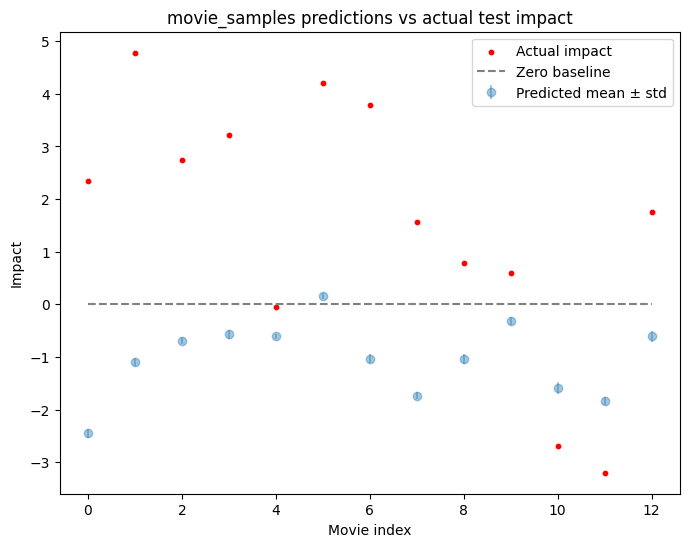

In [ ]:

movie_pred_mean = movie_samples.mean(dim=1)
movie_pred_std = movie_samples.std(dim=1)

comparison = torch.stack([movie_pred_mean, movie_pred_std, test_impactv2], dim=1)
print("Predicted mean | Predicted std | Actual impact")
print(comparison[:10])

movie_mae = torch.mean(torch.abs(movie_pred_mean - test_impactv2))
movie_rmse = torch.sqrt(torch.mean((movie_pred_mean - test_impactv2) ** 2))

baseline_pred = torch.zeros_like(test_impactv2)
baseline_mae = torch.mean(torch.abs(baseline_pred - test_impactv2))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - test_impactv2) ** 2))

print(f"movie_samples vs test_impactv2:\n  MAE = {movie_mae.item():.4f}\n  RMSE = {movie_rmse.item():.4f}")
print(f"zero baseline vs test_impactv2:\n  MAE = {baseline_mae.item():.4f}\n  RMSE = {baseline_rmse.item():.4f}")

plt.figure(figsize=(8, 6))
plt.errorbar(
    range(len(movie_pred_mean)),
    movie_pred_mean.numpy(),
    yerr=movie_pred_std.numpy(),
    fmt='o',
    alpha=0.4,
    label='Predicted mean ± std'
)
plt.scatter(range(len(test_impactv2)), test_impactv2.numpy(), color='red', s=10, label='Actual impact')
plt.plot(range(len(baseline_pred)), baseline_pred.numpy(), color='gray', linestyle='--', label='Zero baseline')
plt.xlabel('Movie index')
plt.ylabel('Impact')
plt.title('movie_samples predictions vs actual test impact')
plt.legend()
plt.show()

## Model 2

In [21]:
def actor_genre_movie_model(genre_matrix, actor_ids, num_actors, obs=None):
    """
    genre_matrix: [N, G]
        One genre vector per movie.

    actor_ids: [N, K]
        Actor IDs per movie.
        0 should mean padding / no actor.
        Real actors should be 1, 2, ..., num_actors.

    num_actors:
        Number of real actors from training data.

    obs: [N]
        Impact per movie.
    """

    actor_ids = actor_ids.long()

    N, num_genres = genre_matrix.shape
    _, K = actor_ids.shape

    alpha = pyro.sample(
        "alpha",
        dist.Normal(0.0, 10.0)
    )

    beta_genre = pyro.sample(
        "beta_genre",
        dist.Normal(
            torch.zeros(num_genres, device=genre_matrix.device),
            torch.ones(num_genres, device=genre_matrix.device)
        ).to_event(1)
    )

    actor_scale = pyro.sample(
        "actor_scale",
        dist.HalfCauchy(5.0)
    )

    # +1 because actor_effect[0] is padding
    actor_effect = pyro.sample(
        "actor_effect",
        dist.Normal(
            torch.zeros(num_actors + 1, device=genre_matrix.device),
            actor_scale * torch.ones(num_actors + 1, device=genre_matrix.device)
        ).to_event(1)
    )

    actor_genre_scale = pyro.sample(
        "actor_genre_scale",
        dist.HalfCauchy(5.0)
    )

    # # +1 because row 0 is padding
    # actor_genre_effect = pyro.sample(
    #     "actor_genre_effect",
    #     dist.Normal(
    #         torch.zeros(num_actors + 1, num_genres, device=genre_matrix.device),
    #         actor_genre_scale * torch.ones(num_actors + 1, num_genres, device=genre_matrix.device)
    #     ).to_event(2)
    # )

    sigma = pyro.sample(
        "sigma",
        dist.HalfCauchy(5.0)
    )

    # Genre main effect
    genre_part = genre_matrix.matmul(beta_genre)

    # Mask:
    # valid if actor id is not padding and is seen in training
    valid_actor_mask = (actor_ids > 0) & (actor_ids <= num_actors)

    # Safe actor IDs for indexing
    safe_actor_ids = actor_ids.clone()
    safe_actor_ids[~valid_actor_mask] = 0

    # Force padding actor effect to zero
    actor_effect = actor_effect.clone()
    actor_effect[0] = 0.0

    # actor_genre_effect = actor_genre_effect.clone()
    # actor_genre_effect[0, :] = 0.0


    num_valid_actors = valid_actor_mask.sum(dim=1).clamp(min=1).float() 
    # General actor contribution
    # actor_effect[safe_actor_ids] has shape [N, K]
    actor_part = actor_effect[safe_actor_ids].sum(dim=1)
    # actor_part = actor_effect[safe_actor_ids].sum(dim=1) / torch.sqrt(num_valid_actors)
    
    # Actor-specific genre contribution
    # actor_genre_effect[safe_actor_ids] has shape [N, K, G]
    # genre_matrix[:, None, :] has shape [N, 1, G]
    # interaction_part = (
    #     actor_genre_effect[safe_actor_ids] * genre_matrix[:, None, :]
    # ).sum(dim=(1, 2))


    # interaction_part = (
    #     actor_genre_effect[safe_actor_ids] * genre_matrix[:, None, :]
    # ).sum(dim=(1, 2)) / torch.sqrt(num_valid_actors)
    mu = alpha + genre_part + actor_part# + interaction_part

    with pyro.plate("data", N):
        y = pyro.sample(
            "y",
            dist.Normal(mu, sigma),
            obs=obs
        )

    return y

In [22]:

train_actor_ids = train_actors.long()       # shape [N, K]
train_genrev2 = train_genres.float()        # shape [N, G]
train_impactv2 = train_impact.float()       # shape [N]

num_train_actors = int(train_actor_ids.max().item())

pyro.clear_param_store()

guide = AutoNormal(actor_genre_movie_model)

optimizer = Adam({"lr": 0.01})

svi = SVI(
    actor_genre_movie_model,
    guide,
    optimizer,
    loss=Trace_ELBO()
)

for step in range(3000):
    loss = svi.step(
        train_genrev2,
        train_actor_ids,
        num_train_actors,
        train_impactv2
    )

    if step % 250 == 0:
        print(f"step {step} loss = {loss:.2f}")

step 0 loss = 33420.84
step 250 loss = 13058.79
step 500 loss = 12870.82
step 750 loss = 12801.75
step 1000 loss = 12891.42
step 1250 loss = 12776.37
step 1500 loss = 12793.81
step 1750 loss = 12768.63
step 2000 loss = 12771.20
step 2250 loss = 12776.33
step 2500 loss = 12767.60
step 2750 loss = 12778.88


In [ ]:
test_actor_ids = test_actors.long()
test_genrev2 = test_genres.float()
test_impactv2 = test_impact.float()

val_actor_ids = val_actors.long()
val_genrev2 = val_genres.float()
val_impactv2 = val_impact.float()

predictive = Predictive(
    actor_genre_movie_model,
    guide=guide,
    num_samples=1000,
    return_sites=("y",)
)

posterior_samples = predictive(
    test_genrev2,
    test_actor_ids,
    num_train_actors,
    obs=None
)

val_sam = predictive(
    val_genrev2,
    val_actor_ids,
    num_train_actors,
    obs=None
)

y_samples = posterior_samples["y"]
y_mean = y_samples.mean(dim=0)
y_std = y_samples.std(dim=0)
y_true = test_impactv2


In [39]:
y_samples = val_sam["y"]
y_mean = y_samples.mean(dim=0)
y_std = y_samples.std(dim=0)
y_true = val_impact


In [40]:

model_mae = torch.mean(torch.abs(y_mean - y_true))
model_rmse = torch.sqrt(torch.mean((y_mean - y_true) ** 2))

baseline_pred = torch.zeros_like(y_true)

baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))

print("Model MAE:", model_mae.item())
print("Baseline MAE:", baseline_mae.item())
print("MAE improvement %:", (100 * (baseline_mae - model_mae) / baseline_mae).item())

print("Model RMSE:", model_rmse.item())
print("Baseline RMSE:", baseline_rmse.item())
print("RMSE improvement %:", (100 * (baseline_rmse - model_rmse) / baseline_rmse).item())

Model MAE: 2.3492069244384766
Baseline MAE: 2.2917680740356445
MAE improvement %: -2.5063116550445557
Model RMSE: 3.0805866718292236
Baseline RMSE: 3.1783602237701416
RMSE improvement %: 3.076226234436035
